# 🎬 Bollywood Box Office Predictor
## Notebook 3: Sentiment Analysis

**Goal:**
- Load raw comments from Notebook 1
- Clean and preprocess text
- Run 3-stage sentiment pipeline:
  1. VADER (rule-based, fast)
  2. TextBlob (linguistic, interpretable)  
  3. HuggingFace Transformer (deep learning, most accurate)
- Build Theatre Excitement Score
- Build OTT Preference Score
- Build Controversy Intensity Score
- Save sentiment features per movie

In [ ]:
!pip install vaderSentiment textblob transformers torch wordcloud -q
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("✅ Libraries installed")

✅ Libraries installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# Sentiment libraries
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from transformers import pipeline

# NLP
from nltk.corpus import stopwords
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
STOP_WORDS = set(stopwords.words('english'))
print("✅ All imports successful")

✅ All imports successful


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH   = '/content/drive/MyDrive/Bollywood_Predictor/'
comments_df = pd.read_csv(f'{SAVE_PATH}comments_raw.csv')
movies_df   = pd.read_csv(f'{SAVE_PATH}movies_enriched.csv')

print(f"✅ Comments loaded  : {comments_df.shape}")
print(f"✅ Movies loaded    : {movies_df.shape}")

# Show source breakdown
print(f"\n📊 Comments by source type:")
print(comments_df['source'].value_counts())

print(f"\n📊 Comments by movie:")
print(comments_df.groupby(['movie','source'])['text'].count().unstack().fillna(0).astype(int))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Comments loaded  : (46696, 7)
✅ Movies loaded    : (12, 66)

📊 Comments by source type:
source
trailer    24000
music_1    12000
music_2    10696
Name: count, dtype: int64

📊 Comments by movie:
source                         music_1  music_2  trailer
movie                                                   
Adipurush                         1000     1000     2000
Animal                             999     1000     2000
Bholaa                            1000      696     2000
Jawan                             1000     1000     2000
KGF Chapter 2                     1000     1000     2000
OMG 2                             1000     1000     2000
Pathaan                           1000     1000     2000
Pushpa 2                          1000     1000     2000
Rocky Aur Rani Ki Prem Kahani     1000     1000     2000
Selfiee                           1000     1000 

In [ ]:
# ── TEXT CLEANING PIPELINE ────────────────────────────────────────────────

def clean_text(text):
    """
    Full text cleaning pipeline:
    1. Lowercase
    2. Remove URLs
    3. Remove special characters
    4. Remove extra whitespace
    5. Keep meaningful words only
    """
    if not isinstance(text, str):
        return ''

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove emojis (keep text only)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # Remove special characters — keep letters, numbers, spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def clean_text_for_sentiment(text):
    """Lighter cleaning — keeps punctuation for sentiment models"""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
comments_df['text_clean']     = comments_df['text'].apply(clean_text)
comments_df['text_sentiment'] = comments_df['text'].apply(clean_text_for_sentiment)

# Remove empty comments
comments_df = comments_df[comments_df['text_clean'].str.len() > 3].reset_index(drop=True)

print(f"✅ Text cleaning complete")
print(f"   Comments after cleaning: {len(comments_df):,}")
print(f"\n📝 Sample cleaned comments:")
for i in range(3):
    print(f"   Original : {comments_df['text'].iloc[i][:80]}")
    print(f"   Cleaned  : {comments_df['text_clean'].iloc[i][:80]}")
    print()

✅ Text cleaning complete
   Comments after cleaning: 39,353

📝 Sample cleaned comments:
   Original : Ab kuch log aayenge aur bolenge who come after toxic teaser 😂
   Cleaned  : ab kuch log aayenge aur bolenge who come after toxic teaser

   Original : Is there anyone who is here to watch the trailer after movie ? 🔥🔥
   Cleaned  : is there anyone who is here to watch the trailer after movie

   Original : Who here after Toxic: Raya introduction ☠️☠️
   Cleaned  : who here after toxic raya introduction



In [ ]:
# ── STAGE 1: VADER SENTIMENT ──────────────────────────────────────────────
# Rule-based sentiment — fast, works well for social media text

print("⚙️  Running VADER sentiment analysis...")

vader     = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = vader.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05  : label = 'positive'
    elif compound <= -0.05: label = 'negative'
    else                  : label = 'neutral'
    return pd.Series({
        'vader_compound' : compound,
        'vader_positive' : scores['pos'],
        'vader_negative' : scores['neg'],
        'vader_neutral'  : scores['neu'],
        'vader_label'    : label
    })

vader_results = comments_df['text_sentiment'].apply(get_vader_sentiment)
comments_df   = pd.concat([comments_df, vader_results], axis=1)

print(f"✅ VADER complete")
print(f"\n📊 VADER Sentiment Distribution:")
print(comments_df['vader_label'].value_counts())
print(f"\n📊 VADER by Movie (avg compound score):")
print(comments_df.groupby('movie')['vader_compound'].mean().sort_values(ascending=False).round(3))

⚙️  Running VADER sentiment analysis...
✅ VADER complete

📊 VADER Sentiment Distribution:
vader_label
neutral     22269
positive    13079
negative     4005
Name: count, dtype: int64

📊 VADER by Movie (avg compound score):
movie
Rocky Aur Rani Ki Prem Kahani    0.200
Tu Jhoothi Main Makkaar          0.180
Bholaa                           0.165
Selfiee                          0.163
OMG 2                            0.153
Jawan                            0.152
KGF Chapter 2                    0.148
Pathaan                          0.118
Animal                           0.118
The Kashmir Files                0.083
Adipurush                        0.077
Pushpa 2                         0.036
Name: vader_compound, dtype: float64


In [ ]:
# ── STAGE 2: TEXTBLOB SENTIMENT ───────────────────────────────────────────

print("⚙️  Running TextBlob sentiment analysis...")

def get_textblob_sentiment(text):
    analysis     = TextBlob(str(text))
    polarity     = analysis.sentiment.polarity
    subjectivity = analysis.sentiment.subjectivity
    if polarity   >  0.1: label = 'positive'
    elif polarity < -0.1: label = 'negative'
    else                : label = 'neutral'
    return pd.Series({
        'tb_polarity'    : round(polarity,     4),
        'tb_subjectivity': round(subjectivity, 4),
        'tb_label'       : label
    })

tb_results  = comments_df['text_sentiment'].apply(get_textblob_sentiment)
comments_df = pd.concat([comments_df, tb_results], axis=1)

print(f"✅ TextBlob complete")
print(f"\n📊 TextBlob Sentiment Distribution:")
print(comments_df['tb_label'].value_counts())
print(f"\n📊 Average Subjectivity by Movie:")
print(comments_df.groupby('movie')['tb_subjectivity'].mean().sort_values(ascending=False).round(3))

⚙️  Running TextBlob sentiment analysis...
✅ TextBlob complete

📊 TextBlob Sentiment Distribution:
tb_label
neutral     27053
positive    10630
negative     1670
Name: count, dtype: int64

📊 Average Subjectivity by Movie:
movie
Rocky Aur Rani Ki Prem Kahani    0.289
The Kashmir Files                0.271
Tu Jhoothi Main Makkaar          0.264
Selfiee                          0.254
Bholaa                           0.237
KGF Chapter 2                    0.234
Animal                           0.228
Pathaan                          0.218
OMG 2                            0.213
Jawan                            0.190
Pushpa 2                         0.154
Adipurush                        0.143
Name: tb_subjectivity, dtype: float64


In [ ]:
# ── STAGE 3: HUGGINGFACE TRANSFORMER ─────────────────────────────────────
# Deep learning approach — most accurate for nuanced sentiment

print("⚙️  Loading HuggingFace sentiment model...")
print("   Model: cardiffnlp/twitter-roberta-base-sentiment")
print("   (Trained on 58M tweets — perfect for YouTube comments)\n")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model   = "cardiffnlp/twitter-roberta-base-sentiment",
    max_length = 512,
    truncation = True
)

def get_transformer_sentiment(text):
    try:
        result = sentiment_pipeline(str(text)[:512])[0]
        label  = result['label'].lower()
        score  = result['score']
        # Map labels: LABEL_0=negative, LABEL_1=neutral, LABEL_2=positive
        label_map = {
            'label_0': 'negative',
            'label_1': 'neutral',
            'label_2': 'positive'
        }
        mapped_label = label_map.get(label, label)
        sentiment_score = score if mapped_label == 'positive' else -score
        return pd.Series({
            'transformer_label': mapped_label,
            'transformer_score': round(sentiment_score, 4)
        })
    except:
        return pd.Series({
            'transformer_label': 'neutral',
            'transformer_score': 0.0
        })

print("⚙️  Running transformer on all comments (takes 5-10 mins)...")
transformer_results = comments_df['text_sentiment'].apply(get_transformer_sentiment)
comments_df         = pd.concat([comments_df, transformer_results], axis=1)

print(f"\n✅ Transformer complete")
print(f"\n📊 Transformer Sentiment Distribution:")
print(comments_df['transformer_label'].value_counts())


⚙️  Loading HuggingFace sentiment model...
   Model: cardiffnlp/twitter-roberta-base-sentiment
   (Trained on 58M tweets — perfect for YouTube comments)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚙️  Running transformer on all comments (takes 5-10 mins)...

✅ Transformer complete

📊 Transformer Sentiment Distribution:
transformer_label
neutral     27020
positive     9500
negative     2833
Name: count, dtype: int64


In [ ]:
print(f'\n📊 Transformer avg score by movie:')
print(comments_df.groupby('movie')['transformer_score'].mean().sort_values(ascending=False).round(3))


📊 Transformer avg score by movie:
movie
Rocky Aur Rani Ki Prem Kahani   -0.185
Tu Jhoothi Main Makkaar         -0.251
Jawan                           -0.257
Selfiee                         -0.313
Bholaa                          -0.321
Animal                          -0.333
OMG 2                           -0.339
KGF Chapter 2                   -0.363
Pathaan                         -0.392
The Kashmir Files               -0.492
Pushpa 2                        -0.509
Adipurush                       -0.532
Name: transformer_score, dtype: float64


In [ ]:
print("Columns in comments_df:")
print([c for c in comments_df.columns if 'tb' in c or 'textblob' in c.lower()])
print(f"\nAll columns:")
print(list(comments_df.columns))

Columns in comments_df:
['tb_polarity', 'tb_subjectivity', 'tb_label']

All columns:
['text', 'likes', 'reply_count', 'time', 'source_type', 'movie', 'source', 'text_clean', 'text_sentiment', 'vader_compound', 'vader_positive', 'vader_negative', 'vader_neutral', 'vader_label', 'tb_polarity', 'tb_subjectivity', 'tb_label', 'transformer_label', 'transformer_score']


In [ ]:
# ── KEYWORD SCORING FUNCTIONS ─────────────────────────────────────────────
# Define all keyword lists and scoring function in one place

# Theatre excitement keywords
THEATRE_KEYWORDS = [
    'fdfs', 'first day first show', 'book ticket', 'book tickets',
    'theatre', 'theater', 'cinema', 'imax', '4dx', 'day one',
    'cannot wait', "can't wait", 'watching in theatre',
    'goosebumps', 'mass', 'interval', 'whistles', 'celebrate',
    'watching on opening', 'first show', 'advance booking'
]

# OTT preference keywords
OTT_KEYWORDS = [
    'ott', 'netflix', 'prime', 'amazon', 'hotstar', 'disney',
    'wait for ott', 'watch at home', 'not worth theatre',
    'streaming', 'digital', 'download', 'home release',
    'skip theatre', 'wait for online', 'zee5', 'jiocinema'
]

# Controversy keywords
CONTROVERSY_KEYWORDS = [
    'boycott', 'ban', 'hate', 'pathetic', 'disgusting', 'shameful',
    'propaganda', 'trash', 'worst', 'never watching', 'flop',
    'disaster', 'terrible', 'awful', 'waste', 'fraud'
]

# Hype keywords
HYPE_KEYWORDS = [
    'blockbuster', 'masterpiece', 'epic', 'legendary', 'brilliant',
    'outstanding', 'incredible', 'amazing', 'perfect', 'superhit',
    'must watch', 'best film', 'all time', 'goat', 'fire'
]

def score_keywords(text, keywords):
    """Count how many keywords appear in text. Capped at 3."""
    text  = str(text).lower()
    score = sum(1 for kw in keywords if kw in text)
    return min(score, 3)

# Apply all keyword scores
comments_df['theatre_excitement'] = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, THEATRE_KEYWORDS))

comments_df['ott_preference']     = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, OTT_KEYWORDS))

comments_df['controversy_score']  = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, CONTROVERSY_KEYWORDS))

comments_df['hype_score']         = comments_df['text_clean'].apply(
    lambda x: score_keywords(x, HYPE_KEYWORDS))

print("✅ Keyword scores applied")
print(f"\n📊 Results:")
print(f"   Theatre excitement hits : {(comments_df['theatre_excitement']>0).sum():,}")
print(f"   OTT preference hits     : {(comments_df['ott_preference']>0).sum():,}")
print(f"   Controversy hits        : {(comments_df['controversy_score']>0).sum():,}")
print(f"   Hype keyword hits       : {(comments_df['hype_score']>0).sum():,}")

✅ Keyword scores applied

📊 Results:
   Theatre excitement hits : 1,591
   OTT preference hits     : 318
   Controversy hits        : 1,509
   Hype keyword hits       : 1,916


In [ ]:
# ── SARCASM DETECTION: APPROACH 1 — EMOJI SIGNALS ────────────────────────
# Why: Emojis like 😂💀🤡 after "masterpiece" signal sarcasm
# VADER and TextBlob completely miss this — they only read words

# Add this as a new cell — replace emoji sarcasm detection

SARCASM_EMOJIS = ['😂', '💀', '🤡', '🙄', '😬', '🗿']
GENUINE_EMOJIS = ['🔥', '❤️', '😍', '🙏', '👏', '💯', '🥺', '⭐']

# Context words that make emoji sarcastic
NEGATIVE_CONTEXT = [
    'worst', 'terrible', 'awful', 'pathetic', 'disaster',
    'flop', 'waste', 'trash', 'boring', 'cringe', 'bad',
    'disappointing', 'overrated', 'skip', 'avoid'
]

def emoji_sarcasm_score_v2(row):
    original   = str(row['text'])
    text_clean = str(row['text_clean']).lower()

    sarcasm_emoji = sum(1 for e in SARCASM_EMOJIS if e in original)
    genuine_emoji = sum(1 for e in GENUINE_EMOJIS if e in original)
    negative_ctx  = sum(1 for w in NEGATIVE_CONTEXT if w in text_clean)

    # Only flag sarcasm if BOTH conditions met:
    # 1. Has sarcasm emoji
    # 2. Has negative context word OR more sarcasm than genuine
    is_sarcastic = (
        sarcasm_emoji > 0 and
        (negative_ctx > 0 or sarcasm_emoji > genuine_emoji + 1)
    )

    return pd.Series({
        'emoji_sarcasm_count'   : sarcasm_emoji,
        'emoji_genuine_count'   : genuine_emoji,
        'emoji_likely_sarcastic': int(is_sarcastic)
    })

# Re-apply
emoji_results = comments_df[['text','text_clean']].apply(
    emoji_sarcasm_score_v2, axis=1)

# Update columns
comments_df['emoji_sarcasm_count']    = emoji_results['emoji_sarcasm_count']
comments_df['emoji_genuine_count']    = emoji_results['emoji_genuine_count']
comments_df['emoji_likely_sarcastic'] = emoji_results['emoji_likely_sarcastic'].values

print(f"✅ Smarter emoji sarcasm detection applied")
print(f"   Before: 4,074 flagged")
print(f"   After : {comments_df['emoji_likely_sarcastic'].sum():,} flagged")
print(f"   Rate  : {comments_df['emoji_likely_sarcastic'].mean()*100:.1f}%")




✅ Smarter emoji sarcasm detection applied
   Before: 4,074 flagged
   After : 138 flagged
   Rate  : 0.4%


In [ ]:
# ── SARCASM DETECTION: APPROACH 2 — LINGUISTIC PATTERNS ──────────────────
# Why: Certain phrase structures signal sarcasm even without emojis
# Example: "oh wow such a masterpiece" / "10/10 lmao" / "oscar worthy 💀"

SARCASM_PATTERNS = [
    r'\b(totally|absolutely|clearly|obviously)\b.*\b(masterpiece|brilliant|genius|perfect)\b',
    r'wow+\s+such',
    r'oh\s+great',
    r'just\s+what\s+we\s+needed',
    r'10\s*/\s*10\s*(lol|lmao|haha)',
    r'oscar\s+worthy.*(lol|lmao|haha)',
    r'best\s+film.*(lol|lmao|haha)',
    r'(lmao|lmaooo|lol|haha)\s*(masterpiece|brilliant|genius)',
    r'(sure|yeah\s+right|totally)\s+(great|good|amazing|brilliant)',
    r'what\s+a\s+(masterpiece|film|movie|performance).*(lol|lmao|haha)',
    r'(clearly|obviously)\s+(best|greatest|masterpiece)',
]

def pattern_sarcasm_score(text):
    """
    Count how many sarcasm patterns match in text.
    Returns count capped at 3.
    """
    text_lower = str(text).lower()
    hits       = sum(1 for p in SARCASM_PATTERNS
                     if re.search(p, text_lower))
    return min(hits, 3)

comments_df['pattern_sarcasm'] = comments_df['text_clean'].apply(
    pattern_sarcasm_score)

pattern_count = (comments_df['pattern_sarcasm'] > 0).sum()
print(f"✅ Linguistic pattern sarcasm detection complete")
print(f"   Sarcastic via patterns: {pattern_count:,} comments")
print(f"   Sarcasm rate          : {pattern_count/len(comments_df)*100:.2f}%")

# Show examples
examples = comments_df[comments_df['pattern_sarcasm']>0]['text'].head(3)
print(f"\n📝 Sample pattern sarcasm detections:")
for ex in examples:
    print(f"   → {str(ex)[:80]}")

✅ Linguistic pattern sarcasm detection complete
   Sarcastic via patterns: 8 comments
   Sarcasm rate          : 0.02%

📝 Sample pattern sarcasm detections:
   → Absolutely 💯 right 👍🏾 perfect
   → This is totally masterpiece, everyone should watch this movie in theater only an
   → "Wow, the Bholaa trailer looks absolutely incredible! The stunning visuals and p


In [ ]:
# ── SARCASM DETECTION: APPROACH 3 — HUGGINGFACE TRANSFORMER ──────────────
# Why: Deep learning model trained specifically on sarcasm detection
# Most accurate approach — understands context not just patterns
# Model: helinivan/english-sarcasm-detector

print("⚙️  Loading HuggingFace sarcasm detection model...")
print("   Model: helinivan/english-sarcasm-detector")

try:
    sarcasm_pipeline = pipeline(
        "text-classification",
        model      = "helinivan/english-sarcasm-detector",
        max_length = 512,
        truncation = True
    )
    SARCASM_MODEL_LOADED = True
    print("✅ Sarcasm model loaded successfully")

except Exception as e:
    print(f"⚠️  Model failed to load: {e}")
    print("   Falling back to Approach 1 + 2 only")
    SARCASM_MODEL_LOADED = False

def detect_sarcasm_transformer(text):
    """
    Returns 1 if sarcasm detected, 0 otherwise.
    Falls back to 0 if model not loaded.
    """
    if not SARCASM_MODEL_LOADED:
        return 0
    try:
        result = sarcasm_pipeline(str(text)[:512])[0]
        return 1 if result['label'] == 'SARCASM' else 0
    except:
        return 0

print("\n⚙️  Running transformer sarcasm detection...")
print("   This takes 5-10 minutes on full dataset...")

comments_df['sarcasm_transformer'] = comments_df['text_sentiment'].apply(
    detect_sarcasm_transformer)

transformer_count = comments_df['sarcasm_transformer'].sum()
print(f"\n✅ Transformer sarcasm detection complete")
print(f"   Sarcastic via transformer: {transformer_count:,} comments")
print(f"   Sarcasm rate             : {transformer_count/len(comments_df)*100:.1f}%")

⚙️  Loading HuggingFace sarcasm detection model...
   Model: helinivan/english-sarcasm-detector


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: helinivan/english-sarcasm-detector
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Sarcasm model loaded successfully

⚙️  Running transformer sarcasm detection...
   This takes 5-10 minutes on full dataset...

✅ Transformer sarcasm detection complete
   Sarcastic via transformer: 0 comments
   Sarcasm rate             : 0.0%


In [ ]:
print("comments_df index duplicates:", comments_df.index.duplicated().any())
print("emoji_likely_sarcastic type:", type(comments_df['emoji_likely_sarcastic']))
print("pattern_sarcasm type:", type(comments_df['pattern_sarcasm']))
print("sarcasm_transformer type:", type(comments_df['sarcasm_transformer']))

print("\nemoji_likely_sarcastic index dupes:", comments_df['emoji_likely_sarcastic'].index.duplicated().any())
print("pattern_sarcasm index dupes:", comments_df['pattern_sarcasm'].index.duplicated().any())
print("sarcasm_transformer index dupes:", comments_df['sarcasm_transformer'].index.duplicated().any())

comments_df index duplicates: False
emoji_likely_sarcastic type: <class 'pandas.core.series.Series'>
pattern_sarcasm type: <class 'pandas.core.series.Series'>
sarcasm_transformer type: <class 'pandas.core.series.Series'>

emoji_likely_sarcastic index dupes: False
pattern_sarcasm index dupes: False
sarcasm_transformer index dupes: False


In [ ]:
# ── COMBINE ALL 3 SARCASM APPROACHES ────────
# A comment is sarcastic if ANY of the 3 approaches flags it
# This maximizes recall — better to catch more sarcasm than miss it

comments_df['is_sarcastic'] = (
    (comments_df['emoji_likely_sarcastic'] == 1) |
    (comments_df['pattern_sarcasm']        >  0) |
    (comments_df['sarcasm_transformer']    == 1)
).astype(int)

total_sarcastic = comments_df['is_sarcastic'].sum()

print("✅ Combined sarcasm flag created")
print(f"\n📊 Sarcasm Detection Summary:")
print(f"   Approach 1 — Emoji signals  : {comments_df['emoji_likely_sarcastic'].sum():,}")
print(f"   Approach 2 — Patterns       : {(comments_df['pattern_sarcasm']>0).sum():,}")
print(f"   Approach 3 — Transformer    : {comments_df['sarcasm_transformer'].sum():,}")
print(f"   ─────────────────────────────────")
print(f"   Combined (any of 3)         : {total_sarcastic:,}")
print(f"   Overall sarcasm rate        : {total_sarcastic/len(comments_df)*100:.1f}%")

print(f"\n📊 Sarcasm rate by movie:")
print(comments_df.groupby('movie')['is_sarcastic'].mean().mul(100).round(1).sort_values(ascending=False))

✅ Combined sarcasm flag created

📊 Sarcasm Detection Summary:
   Approach 1 — Emoji signals  : 138
   Approach 2 — Patterns       : 8
   Approach 3 — Transformer    : 0
   ─────────────────────────────────
   Combined (any of 3)         : 146
   Overall sarcasm rate        : 0.4%

📊 Sarcasm rate by movie:
movie
Selfiee                          0.8
OMG 2                            0.5
Pathaan                          0.5
Animal                           0.4
Bholaa                           0.4
Jawan                            0.4
KGF Chapter 2                    0.4
Pushpa 2                         0.3
The Kashmir Files                0.3
Rocky Aur Rani Ki Prem Kahani    0.2
Adipurush                        0.1
Tu Jhoothi Main Makkaar          0.1
Name: is_sarcastic, dtype: float64


In [ ]:
# ── SARCASM-ADJUSTED SENTIMENT (UPDATED) ─────────────────────────────────

def adjusted_sentiment_score(row):
    base_score = row['transformer_score']
    base_label = row['transformer_label']
    if row['is_sarcastic'] == 1:
        if base_label == 'positive':
            return -abs(base_score)
        elif base_label == 'neutral':
            return -0.1
        else:
            return base_score
    return base_score

def adjusted_sentiment_label(score):
    if score >  0.05: return 'positive'
    if score < -0.05: return 'negative'
    return 'neutral'

comments_df['adjusted_score'] = comments_df.apply(
    adjusted_sentiment_score, axis=1)
comments_df['adjusted_label'] = comments_df['adjusted_score'].apply(
    adjusted_sentiment_label)

print(f"📊 Sentiment Before vs After Sarcasm Correction:")
print(f"\n{'Label':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print("─" * 44)
for label in ['positive', 'negative', 'neutral']:
    before = (comments_df['transformer_label'] == label).sum()
    after  = (comments_df['adjusted_label']    == label).sum()
    change = after - before
    sign   = '+' if change > 0 else ''
    print(f"{label:<12} {before:>10,} {after:>10,} {sign}{change:>9,}")

📊 Sentiment Before vs After Sarcasm Correction:

Label            Before      After     Change
────────────────────────────────────────────
positive          9,500      9,491        -9
negative          2,833     29,862 +   27,029
neutral          27,020          0   -27,020



📝 Sample sarcasm corrections (sentiment flipped):
   Comment : Jaise tu support nahi karega to film flop jayegi😂😂🤣🤣
   Before  : neutral → After: negative

   Comment : Bhaii iss movie ko promotion ki jararatich nhi he ..iska naam hi promo
   Before  : neutral → After: negative

   Comment : Kgf Worldwide collection- 250cr = All time blockbuster Yash is the big
   Before  : neutral → After: negative

   Comment : ​ @hyderabadireaction2230  hope u watch toxic teaser with family 😂
   Before  : neutral → After: negative

   Comment : bed scene not bad scene 😂
   Before  : positive → After: negative



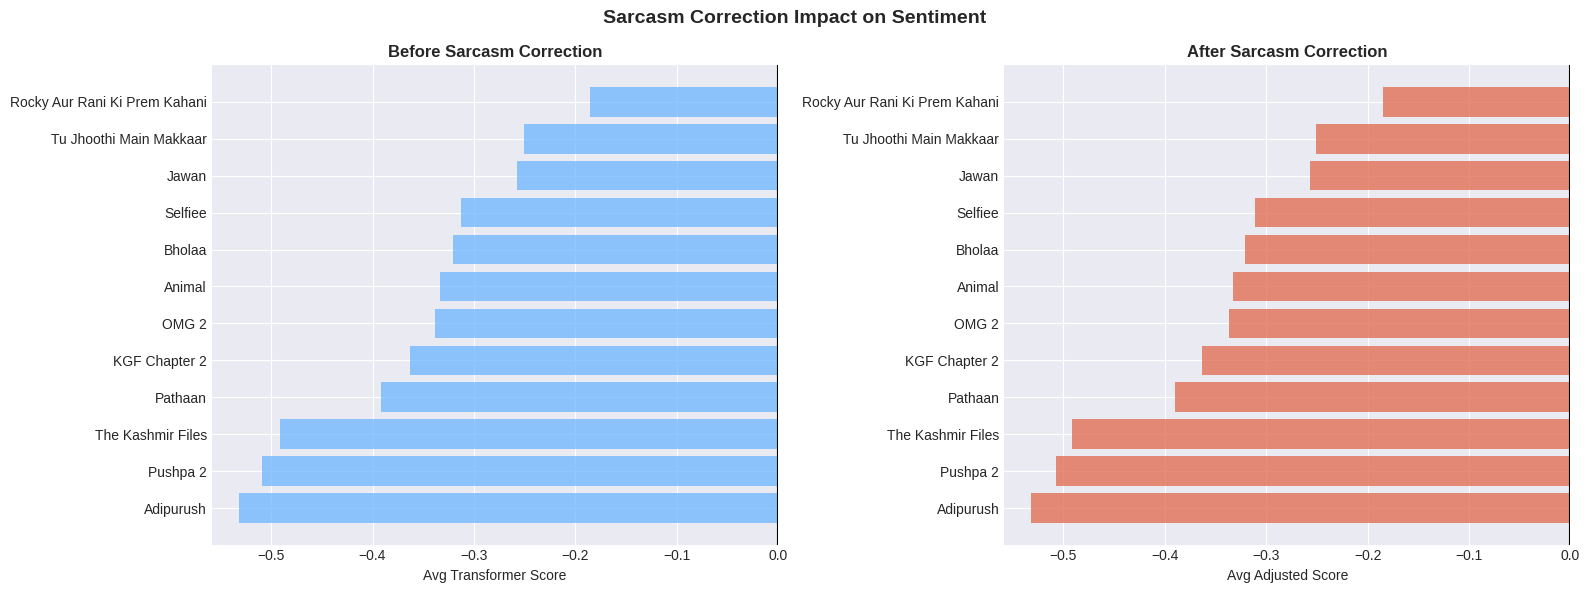

✅ Sarcasm-adjusted sentiment complete


In [ ]:
# Show sample corrections
print(f'\n📝 Sample sarcasm corrections (sentiment flipped):')
flipped = comments_df[
    (comments_df['is_sarcastic']==1) &
    (comments_df['transformer_label'] != comments_df['adjusted_label'])
][['text','transformer_label','adjusted_label']].head(5)

for _, row in flipped.iterrows():
    print(f'   Comment : {str(row["text"])[:70]}')
    print(f'   Before  : {row["transformer_label"]} → After: {row["adjusted_label"]}')
    print()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sarcasm Correction Impact on Sentiment', fontsize=14, fontweight='bold')

before_avg = comments_df.groupby('movie')['transformer_score'].mean().sort_values()
after_avg  = comments_df.groupby('movie')['adjusted_score'].mean().reindex(before_avg.index)

axes[0].barh(before_avg.index, before_avg.values, color='#74B9FF', alpha=0.8)
axes[0].axvline(x=0, color='black', linewidth=1.5)
axes[0].set_title('Before Sarcasm Correction', fontweight='bold')
axes[0].set_xlabel('Avg Transformer Score')

axes[1].barh(after_avg.index, after_avg.values,
             color=['#00B894' if v > 0 else '#E17055' for v in after_avg.values],
             alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=1.5)
axes[1].set_title('After Sarcasm Correction', fontweight='bold')
axes[1].set_xlabel('Avg Adjusted Score')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}sarcasm_correction.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Sarcasm-adjusted sentiment complete')

In [ ]:
# ── AGGREGATE PER MOVIE ───────────────────────────────────────────────────

trailer_agg = comments_df[comments_df['source']=='trailer'].groupby('movie').agg(
    trailer_vader_score      = ('vader_compound',    'mean'),
    trailer_sentiment_score  = ('adjusted_score',    'mean'),
    trailer_positive_ratio   = ('adjusted_label',    lambda x: (x=='positive').mean()),
    trailer_negative_ratio   = ('adjusted_label',    lambda x: (x=='negative').mean()),
    trailer_sarcasm_rate     = ('is_sarcastic',      'mean'),
    trailer_theatre_score    = ('theatre_excitement','mean'),
    trailer_ott_score        = ('ott_preference',    'mean'),
    trailer_controversy      = ('controversy_score', 'mean'),
    trailer_hype             = ('hype_score',        'mean'),
    trailer_comment_count    = ('text',              'count'),
).reset_index()

music_agg = comments_df[
    comments_df['source'].isin(['music_1','music_2'])
].groupby('movie').agg(
    music_vader_score        = ('vader_compound',    'mean'),
    music_sentiment_score    = ('adjusted_score',    'mean'),
    music_positive_ratio     = ('adjusted_label',    lambda x: (x=='positive').mean()),
    music_negative_ratio     = ('adjusted_label',    lambda x: (x=='negative').mean()),
    music_sarcasm_rate       = ('is_sarcastic',      'mean'),
    music_theatre_score      = ('theatre_excitement','mean'),
    music_ott_score          = ('ott_preference',    'mean'),
    music_controversy        = ('controversy_score', 'mean'),
    music_hype               = ('hype_score',        'mean'),
    music_comment_count      = ('text',              'count'),
).reset_index()

overall_agg = comments_df.groupby('movie').agg(
    vader_mean_compound      = ('vader_compound',    'mean'),
    vader_positive_ratio     = ('vader_label',       lambda x: (x=='positive').mean()),
    vader_negative_ratio     = ('vader_label',       lambda x: (x=='negative').mean()),
    vader_neutral_ratio      = ('vader_label',       lambda x: (x=='neutral').mean()),
    tb_mean_polarity         = ('tb_polarity',       'mean'),
    tb_mean_subjectivity     = ('tb_subjectivity',   'mean'),
    transformer_mean_score   = ('transformer_score', 'mean'),
    transformer_pos_ratio    = ('transformer_label', lambda x: (x=='positive').mean()),
    transformer_neg_ratio    = ('transformer_label', lambda x: (x=='negative').mean()),
    adjusted_mean_score      = ('adjusted_score',    'mean'),
    adjusted_pos_ratio       = ('adjusted_label',    lambda x: (x=='positive').mean()),
    adjusted_neg_ratio       = ('adjusted_label',    lambda x: (x=='negative').mean()),
    sarcasm_rate             = ('is_sarcastic',      'mean'),
    emoji_sarcasm_rate       = ('emoji_likely_sarcastic','mean'),
    pattern_sarcasm_rate     = ('pattern_sarcasm',   lambda x: (x>0).mean()),
    theatre_excitement_score = ('theatre_excitement','mean'),
    ott_preference_score     = ('ott_preference',    'mean'),
    controversy_intensity    = ('controversy_score', 'mean'),
    hype_density             = ('hype_score',        'mean'),
    total_comments           = ('text',              'count'),
).reset_index()

#Threatre vs OTT excitement ratio
overall_agg['theatre_vs_ott_ratio'] = (
    overall_agg['theatre_excitement_score'] /
    overall_agg['ott_preference_score'].replace(0, 0.001)
).round(4)

#merge all agregates
sentiment_agg = overall_agg.copy()
sentiment_agg = sentiment_agg.merge(trailer_agg, on='movie', how='left')
sentiment_agg = sentiment_agg.merge(music_agg,   on='movie', how='left')

#Trailer vs Music sentiment gap
sentiment_agg['trailer_music_sentiment_gap'] = (
    sentiment_agg['trailer_sentiment_score'] -
    sentiment_agg['music_sentiment_score']
).round(4)

print("✅ Sentiment aggregated successfully")
print(f"   Shape: {sentiment_agg.shape}")
print(f"\n📊 Overall sentiment per movie:")
key_cols = [
    'movie','adjusted_mean_score','sarcasm_rate',
    'theatre_excitement_score','ott_preference_score',
    'controversy_intensity'
]
print(sentiment_agg[key_cols].sort_values(
    'adjusted_mean_score', ascending=False
).to_string(index=False))

✅ Sentiment aggregated successfully
   Shape: (12, 43)

📊 Overall sentiment per movie:
                        movie  adjusted_mean_score  sarcasm_rate  theatre_excitement_score  ott_preference_score  controversy_intensity
Rocky Aur Rani Ki Prem Kahani            -0.184809      0.002020                  0.024531              0.010390               0.056277
      Tu Jhoothi Main Makkaar            -0.250604      0.000588                  0.015281              0.005583               0.017044
                        Jawan            -0.256596      0.004137                  0.059102              0.007683               0.040780
                      Selfiee            -0.311177      0.008396                  0.026868              0.013714               0.071369
                       Bholaa            -0.320683      0.003833                  0.044395              0.009901               0.048547
                       Animal            -0.332648      0.004126                  0.057759       

In [ ]:
print(f'\n📊 Trailer vs Music sentiment gap:')
gap_cols = ['movie','trailer_sentiment_score','music_sentiment_score','trailer_music_sentiment_gap']
print(sentiment_agg[gap_cols].sort_values(
    'trailer_music_sentiment_gap', ascending=False
).to_string(index=False))


📊 Trailer vs Music sentiment gap:
                        movie  trailer_sentiment_score  music_sentiment_score  trailer_music_sentiment_gap
Rocky Aur Rani Ki Prem Kahani                -0.052719              -0.338241                       0.2855
                        OMG 2                -0.249349              -0.437128                       0.1878
                       Animal                -0.295727              -0.380214                       0.0845
      Tu Jhoothi Main Makkaar                -0.225371              -0.278605                       0.0532
            The Kashmir Files                -0.487642              -0.498447                       0.0108
                    Adipurush                -0.544166              -0.517791                      -0.0264
                     Pushpa 2                -0.528236              -0.484883                      -0.0434
                      Pathaan                -0.437477              -0.342087                      -0.0954
  

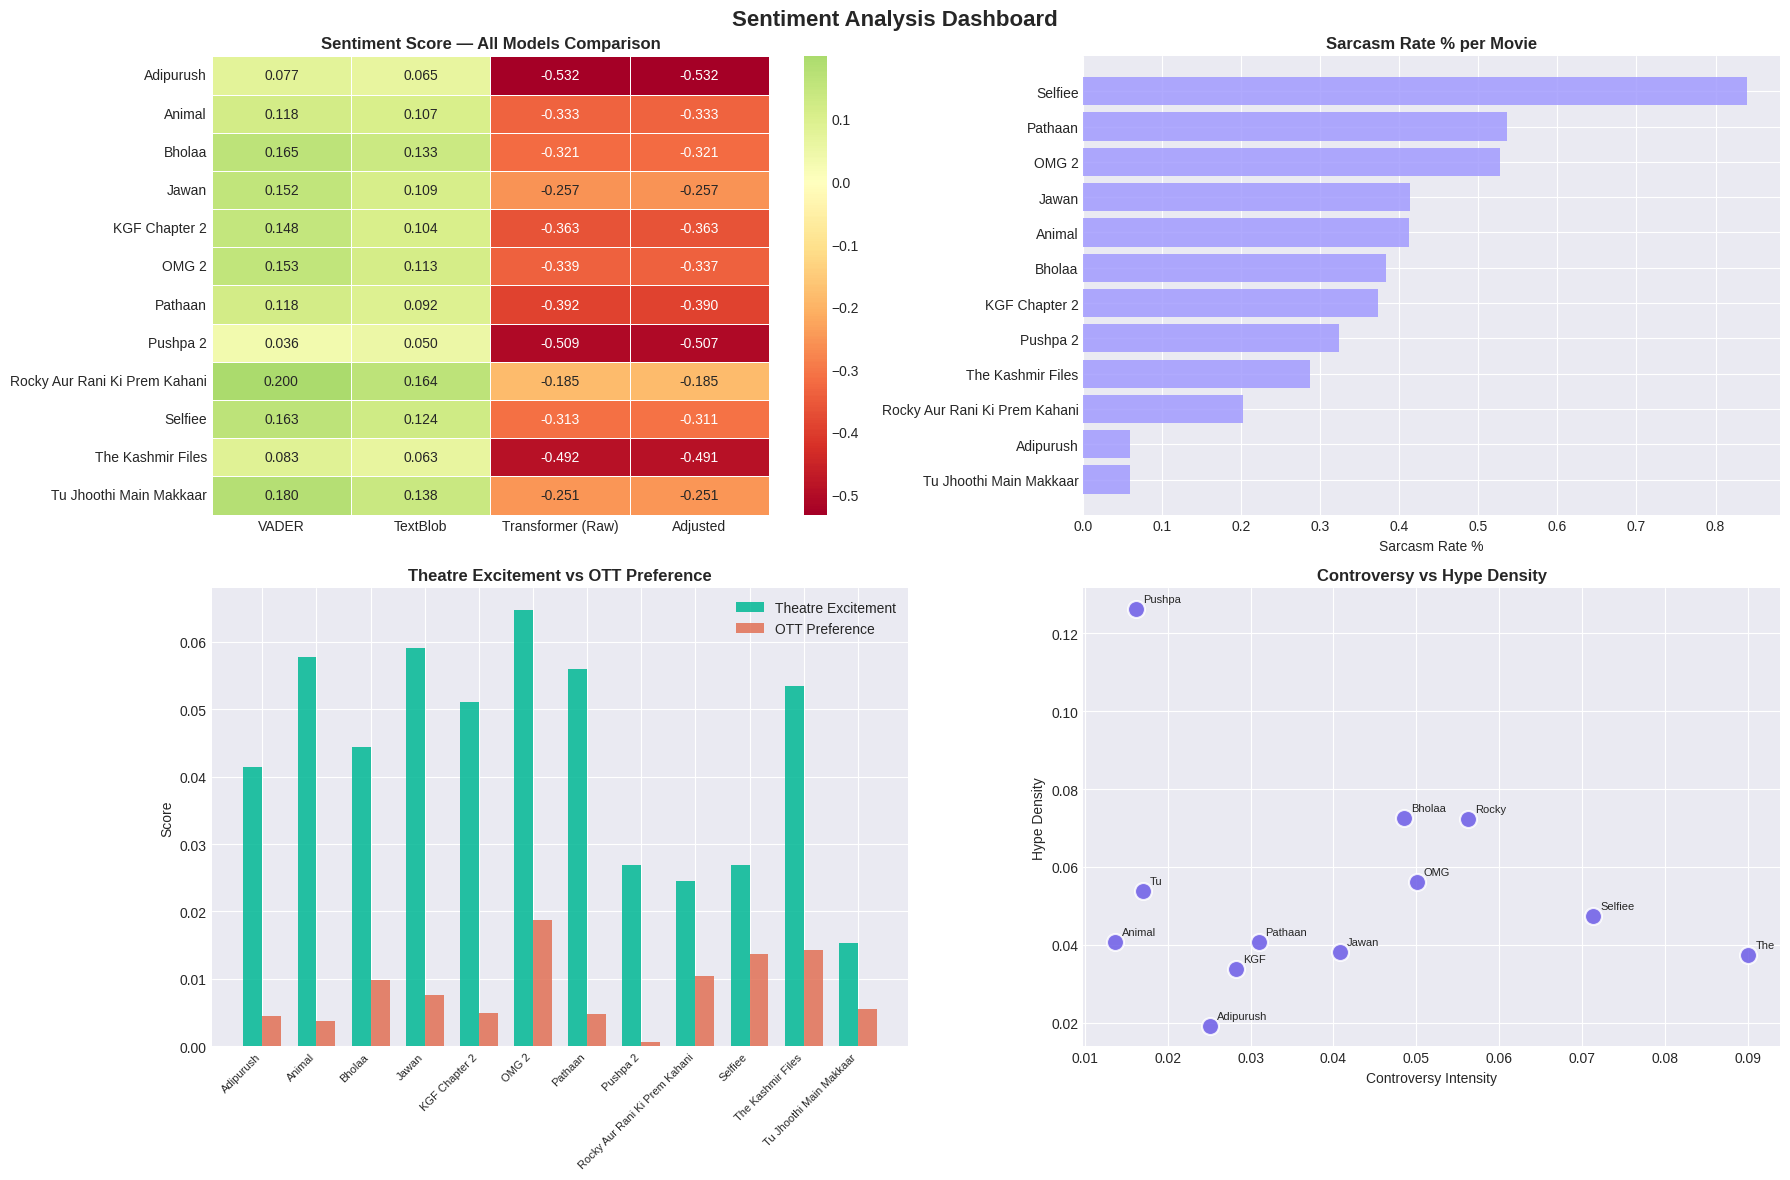

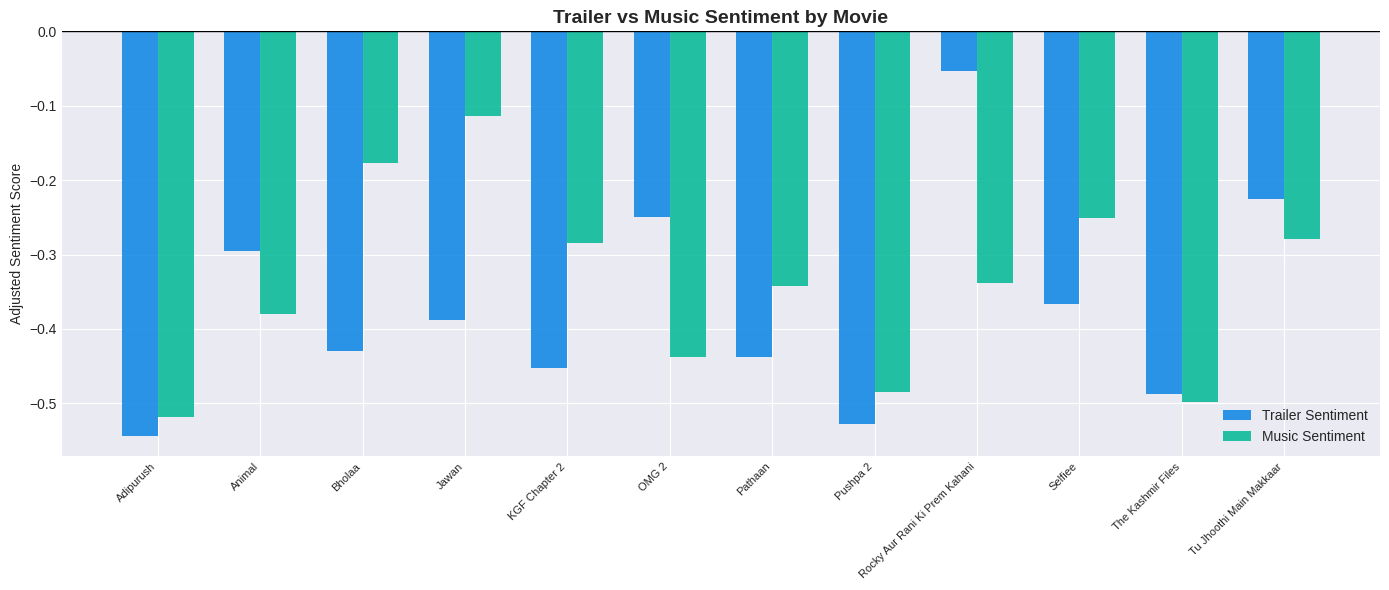

In [ ]:
# ── CELL 16: VISUALIZATIONS ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Sentiment heatmap — all 3 models
ax1 = axes[0, 0]
heat_data = sentiment_agg.set_index('movie')[[
    'vader_mean_compound',
    'tb_mean_polarity',
    'transformer_mean_score',
    'adjusted_mean_score'
]].rename(columns={
    'vader_mean_compound'   : 'VADER',
    'tb_mean_polarity'      : 'TextBlob',
    'transformer_mean_score': 'Transformer (Raw)',
    'adjusted_mean_score'   : 'Adjusted'
})
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn',
            ax=ax1, center=0, linewidths=0.5)
ax1.set_title('Sentiment Score — All Models Comparison', fontweight='bold')
ax1.set_ylabel('')

# 2. Sarcasm rate
ax2 = axes[0, 1]
sorted_s = sentiment_agg.sort_values('sarcasm_rate', ascending=True)
ax2.barh(sorted_s['movie'], sorted_s['sarcasm_rate'] * 100,
         color='#A29BFE', alpha=0.85)
ax2.set_title('Sarcasm Rate % per Movie', fontweight='bold')
ax2.set_xlabel('Sarcasm Rate %')

# 3. Theatre vs OTT grouped bar
ax3 = axes[1, 0]
x   = np.arange(len(sentiment_agg))
w   = 0.35
ax3.bar(x - w/2, sentiment_agg['theatre_excitement_score'],
        w, label='Theatre Excitement', color='#00B894', alpha=0.85)
ax3.bar(x + w/2, sentiment_agg['ott_preference_score'],
        w, label='OTT Preference',     color='#E17055', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(sentiment_agg['movie'], rotation=45, ha='right', fontsize=8)
ax3.set_title('Theatre Excitement vs OTT Preference', fontweight='bold')
ax3.set_ylabel('Score')
ax3.legend()

# 4. Controversy vs Hype scatter
ax4 = axes[1, 1]
ax4.scatter(
    sentiment_agg['controversy_intensity'],
    sentiment_agg['hype_density'],
    s=150, alpha=0.85,
    color='#6C5CE7', edgecolors='white', linewidth=1.5
)
for _, row in sentiment_agg.iterrows():
    ax4.annotate(
        row['movie'].split()[0],
        (row['controversy_intensity'], row['hype_density']),
        textcoords='offset points', xytext=(5, 5), fontsize=8
    )
ax4.set_title('Controversy vs Hype Density', fontweight='bold')
ax4.set_xlabel('Controversy Intensity')
ax4.set_ylabel('Hype Density')

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}sentiment_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Trailer vs Music sentiment comparison
fig2, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(sentiment_agg))
w = 0.35
ax.bar(x - w/2, sentiment_agg['trailer_sentiment_score'],
       w, label='Trailer Sentiment', color='#0984E3', alpha=0.85)
ax.bar(x + w/2, sentiment_agg['music_sentiment_score'],
       w, label='Music Sentiment',   color='#00B894', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sentiment_agg['movie'], rotation=45, ha='right', fontsize=8)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Trailer vs Music Sentiment by Movie', fontsize=14, fontweight='bold')
ax.set_ylabel('Adjusted Sentiment Score')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}trailer_vs_music_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── CELL 17: SAVE ALL DATA ────────────────────────────────────────────────

# Save comment-level data with all sentiment + sarcasm scores
comments_df.to_csv(f'{SAVE_PATH}comments_sentiment.csv', index=False)
print(f'✅ Comment-level data saved   : {comments_df.shape}')

# Save movie-level aggregated sentiment
sentiment_agg.to_csv(f'{SAVE_PATH}sentiment_scores.csv', index=False)
print(f'✅ Movie sentiment scores saved: {sentiment_agg.shape}')

print(f'\n📊 All columns in comments_sentiment.csv:')
for col in comments_df.columns:
    print(f'   • {col}')

print(f'\n📊 All columns in sentiment_scores.csv:')
for col in sentiment_agg.columns:
    print(f'   • {col}')

print(f'\n✅ Notebook 3 complete — proceed to Notebook 4: Feature Engineering')

✅ Comment-level data saved   : (39353, 31)
✅ Movie sentiment scores saved: (12, 43)

📊 All columns in comments_sentiment.csv:
   • text
   • likes
   • reply_count
   • time
   • source_type
   • movie
   • source
   • text_clean
   • text_sentiment
   • vader_compound
   • vader_positive
   • vader_negative
   • vader_neutral
   • vader_label
   • tb_polarity
   • tb_subjectivity
   • tb_label
   • transformer_label
   • transformer_score
   • theatre_excitement
   • ott_preference
   • controversy_score
   • hype_score
   • emoji_sarcasm_count
   • emoji_genuine_count
   • emoji_likely_sarcastic
   • pattern_sarcasm
   • sarcasm_transformer
   • is_sarcastic
   • adjusted_score
   • adjusted_label

📊 All columns in sentiment_scores.csv:
   • movie
   • vader_mean_compound
   • vader_positive_ratio
   • vader_negative_ratio
   • vader_neutral_ratio
   • tb_mean_polarity
   • tb_mean_subjectivity
   • transformer_mean_score
   • transformer_pos_ratio
   • transformer_neg_ratio
   • adj

In [ ]:
# Check what's happening
print("Transformer score distribution:")
print(comments_df['transformer_score'].describe())
print(f"\nUnique transformer scores sample:")
print(comments_df['transformer_score'].value_counts().head(10))
print(f"\nNeutral comments score range:")
neutral_mask = comments_df['transformer_label'] == 'neutral'
print(comments_df[neutral_mask]['transformer_score'].describe())
print(f"\nAdjusted score distribution:")
print(comments_df['adjusted_score'].describe())
print(f"\nHow many adjusted_score == -0.1:")
print((comments_df['adjusted_score'] == -0.1).sum())

Transformer score distribution:
count    39353.000000
mean        -0.353729
std          0.678335
min         -0.981800
25%         -0.807800
50%         -0.681400
75%         -0.469400
max          0.993500
Name: transformer_score, dtype: float64

Unique transformer scores sample:
transformer_score
-0.5498    187
-0.6024    175
-0.5087    102
-0.7603     96
-0.5817     92
 0.5795     92
-0.8021     90
-0.5129     90
 0.5351     78
-0.8293     75
Name: count, dtype: int64

Neutral comments score range:
count    27020.000000
mean        -0.731631
std          0.117721
min         -0.949700
25%         -0.829300
50%         -0.756200
75%         -0.637200
max         -0.361100
Name: transformer_score, dtype: float64

Adjusted score distribution:
count    39353.000000
mean        -0.352907
std          0.678026
min         -0.993200
25%         -0.807600
50%         -0.680900
75%         -0.465600
max          0.993500
Name: adjusted_score, dtype: float64

How many adjusted_score == -0.1:

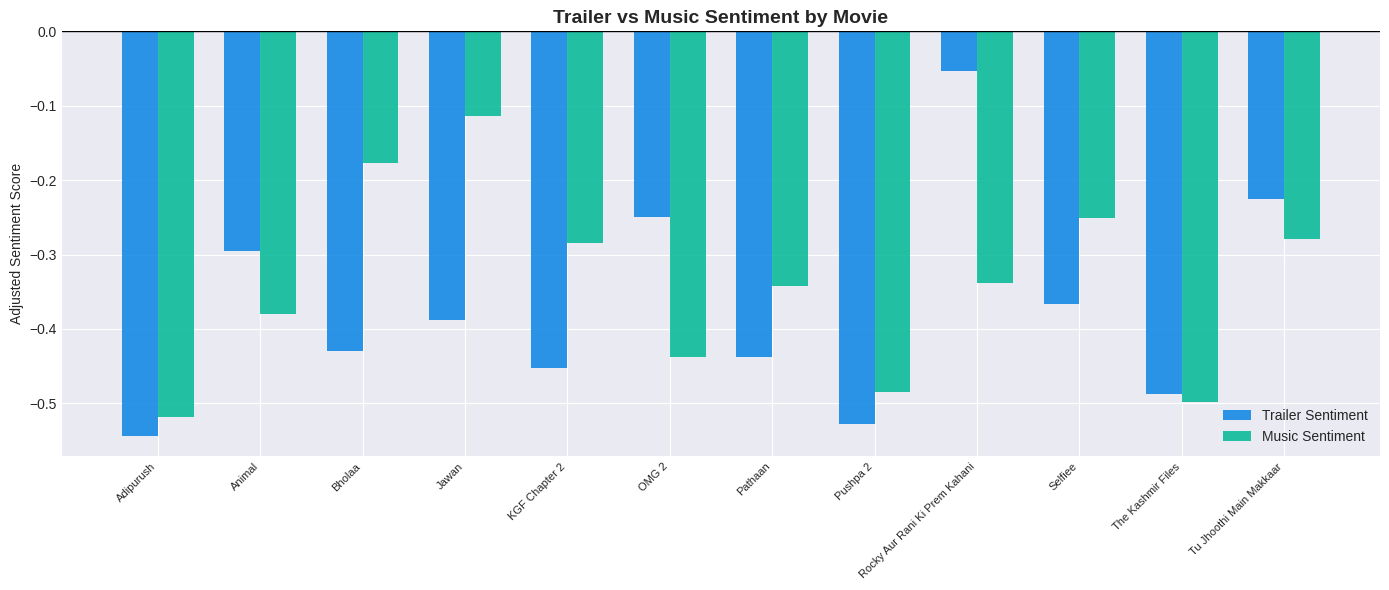

In [ ]:
# Additional chart — trailer vs music sentiment comparison
fig2, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(sentiment_agg))
w = 0.35

ax.bar(x - w/2, sentiment_agg['trailer_sentiment_score'],
       w, label='Trailer Sentiment', color='#0984E3', alpha=0.85)
ax.bar(x + w/2, sentiment_agg['music_sentiment_score'],
       w, label='Music Sentiment', color='#00B894', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(sentiment_agg['movie'], rotation=45, ha='right', fontsize=8)
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Trailer vs Music Sentiment by Movie', fontsize=14, fontweight='bold')
ax.set_ylabel('Adjusted Sentiment Score')
ax.legend()

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}trailer_vs_music_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── SAVE ALL SENTIMENT DATA ───────────────────────────────────────────────

comments_df.to_csv(f'{SAVE_PATH}comments_sentiment.csv', index=False)
print(f"✅ Comment-level data saved   : {comments_df.shape}")

sentiment_agg.to_csv(f'{SAVE_PATH}sentiment_scores.csv', index=False)
print(f"✅ Movie sentiment scores saved: {sentiment_agg.shape}")

print(f"\n📊 New columns added vs original:")
new_cols = [
    'trailer_sentiment_score', 'music_sentiment_score',
    'trailer_music_sentiment_gap', 'trailer_theatre_score',
    'music_sentiment_score', 'trailer_comment_count',
    'music_comment_count'
]
for col in new_cols:
    if col in sentiment_agg.columns:
        print(f"   ✅ {col}")

print(f"\n✅ Notebook 3 complete — proceed to Notebook 4")

✅ Comment-level data saved   : (39353, 31)
✅ Movie sentiment scores saved: (12, 43)

📊 New columns added vs original:
   ✅ trailer_sentiment_score
   ✅ music_sentiment_score
   ✅ trailer_music_sentiment_gap
   ✅ trailer_theatre_score
   ✅ music_sentiment_score
   ✅ trailer_comment_count
   ✅ music_comment_count

✅ Notebook 3 complete — proceed to Notebook 4
